<a href="https://colab.research.google.com/github/theaok/hfgi/blob/main/hfgi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://dataverse.harvard.edu/file.xhtml?fileId=13094135&version=3.1

using
flourishingCountyYear.csv

TODO invite some of the authors of the data start with
Iacus, Stefano Maria and if not ask to rec co-author need someone familiar with data

TODO: also add lina+maria zafiro(shes gis), and rubia (wants to work on papers now)

add more wellbeing vars like altruism optimism etc and yes one paper on swb, but another on morality/ethics following
"Materialism and immorality: more urban than rural?"



https://arxiv.org/pdf/2511.03915
they have
4.4 Rural–Urban Differences in Expressed Well-Being
Indicators tied to religious faith
and moral virtue (believegod, relcomfort, forgive, lovedgod), as well as happiness and purpose
(lifesat, purpose, balance, volunteer), show higher prevalence in rural counties.

FUTURE/LATER

can do did of some interventions bc have time :)

can just graph it (and then confirm with reg with interaction)
difference-in-differences (DiD) is literally just subtracting differences. You calculate the change over time for your treatment group, calculate the change over time for your control group, and then subtract the control group's change from the treatment group's change

# prep

### get data

In [225]:
import time
start_time = time.time()

#can optimize for gpu later: https://www.google.com/search?q=how+to+run+pandas+on+gpu

In [226]:
#---------------------------SETUP----------------------------------
#get useful libraries
import io, time, os, sys, re #basics
import zipfile, json, datetime, string   #string for annotating points in scatter
import urllib.request
import numpy as np #basic math
from statistics import * #stats

import matplotlib.pyplot as plt #import pylab as plt #apparently discouraged now:
 #https://stackoverflow.com/questions/11469336/what-is-the-difference-between-pylab-and-pyplot
 #https://www.tutorialspoint.com/matplotlib/matplotlib_pylab_module.htm

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import urllib  #weird, guess need to have os and pandas imported for this to work  %TODO/LATER ditch it, its weird anyway, just use wget/curl

from google.colab import files

#import webbrowser

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

#many tricks how to extend notebook functionality
#https://coderzcolumn.com/tutorials/python/list-of-useful-magic-commands-in-jupyter-notebook-lab
#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#MAGICS and THEMES/STYLES: important! does affect not just shading/colors, but also fonts, spacing, etc
#(even if you only select default (v not selecting anything) [but does seem to work better if you do make explicit sleections])

###magics: https://ipython.readthedocs.io/en/stable/interactive/magics.html
#most essential setup for vis: it does affect vis! careful!! stick with inline, maybe notebook; others mostly for non-notebook, eg spyder environ
#https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html recomends *inline*!
#show current one:
#%matplotlib
#%matplotlib --list
#interactive plots:
#%matplotlib notebook
#static images of your plot:
%matplotlib inline
#may play with this one and other magics (btw default is probably agg)
#%matplotlib nbagg
##https://www.marktechpost.com/2023/10/20/6-magic-commands-for-jupyter-notebooks-in-python-data-science/
#%%latex
#%ai
#%run
#%writefile
#%history -n

###themes/styles: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html
#https://matplotlib.org/stable/tutorials/introductory/customizing.html
#here more about art and style than under the hood functionality as with magics, explore and experiment
#many may find 'default' or seaborn ones more pleasing; my fav 'classic' is back from 90s ;)
#plt.style.available #list available styles :) may install more
#plt.style.use('default') # more delicate subtle than classic
plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting

#sometimes have to install library which you get from https://pypi.org/
#!pip install geopandas

import statsmodels.formula.api as sm


import geopandas as gpd
import mapclassify

In [227]:
df=pd.read_csv('https://rutgers.box.com/shared/static/l7f4uiev8ju8b6xho2w0tbeplqdkxfle.zip')

/tmp/ipykernel_1300/2070100474.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('https://rutgers.box.com/shared/static/l7f4uiev8ju8b6xho2w0tbeplqdkxfle.zip')


In [228]:
df.shape

(2340928, 11)

In [229]:
df.columns

Index(['variable', 'stat', 'stat_se', 'salience', 'ntweets', 'validtweets', 'natweets', 'FIPS', 'county', 'StateCounty', 'year'], dtype='object')

In [230]:
df.head(15)

,variable,stat,stat_se,salience,ntweets,validtweets,natweets,FIPS,county,StateCounty,year
0,loneliness,NaN,NaN,0.00,1,0,1,36.00,119.00,36119,2010
1,charity,NaN,NaN,0.00,1,0,1,6.00,83.00,06083,2010
2,jobsat,-1.00,NaN,1.00,1,1,0,31.00,55.00,31055,2010
3,purpose,-1.00,NaN,1.00,1,1,0,31.00,55.00,31055,2010
4,optimism,1.00,NaN,1.00,1,1,0,55.00,79.00,55079,2010
5,drinkhealth,NaN,NaN,0.00,1,0,1,48.00,451.00,48451,2011
6,healthlim,1.00,NaN,0.50,2,1,1,34.00,17.00,34017,2011
7,volunteer,NaN,NaN,0.00,1,0,1,18.00,57.00,18057,2011
8,optimism,NaN,NaN,0.00,1,0,1,31.00,119.00,31119,2011
9,goodpromo,NaN,NaN,0.00,1,0,1,37.00,81.00,37081,2011


In [231]:
pd.set_option('display.max_rows', None)
df.variable.value_counts() #lifesat for now

,count
variable,
loneliness,37873
charity,37873
jobsat,37873
purpose,37873
optimism,37873
drinkhealth,37873
healthlim,37873
volunteer,37873
goodpromo,37873


In [232]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
df.ntweets.describe()

,ntweets
count,2340928.00
mean,61449.18
std,386376.78
min,1.00
25%,208.00
50%,2129.00
75%,15517.25
max,32699771.00


In [233]:
df = df[df['variable'] == 'lifesat']

In [234]:
pd.set_option('display.max_rows', None)
df.ntweets.describe()

,ntweets
count,37873.00
mean,69057.64
std,409042.14
min,1.00
25%,485.00
50%,3203.00
75%,19822.00
max,32699771.00


In [235]:
df = df[df['ntweets'] > 500] #do note validtweets is as low as >65 and <100 for like 20obs
df.shape
df.year.value_counts()

(28265, 11)

,count
year,
2014,3101
2013,3079
2015,2945
2018,2595
2019,2551
2020,2468
2017,2465
2021,2370
2022,2257


In [236]:
df.head(100)

,variable,stat,stat_se,salience,ntweets,validtweets,natweets,FIPS,county,StateCounty,year
84,lifesat,-0.20,0.69,0.35,1101,367,734,28.00,67.00,28067,2012
779,lifesat,-0.20,0.09,0.37,82345,30352,51993,26.00,149.00,26149,2013
780,lifesat,-0.19,0.14,0.38,31628,11708,19920,39.00,135.00,39135,2013
781,lifesat,-0.19,0.11,0.37,68801,24905,43896,21.00,179.00,21179,2013
782,lifesat,-0.20,0.14,0.36,38191,13621,24570,22.00,75.00,22075,2013
783,lifesat,-0.18,0.14,0.36,37392,13199,24193,1.00,31.00,01031,2013
1111,lifesat,-0.20,0.35,0.37,5517,2005,3512,20.00,205.00,20205,2013
1112,lifesat,-0.18,0.25,0.36,10998,3992,7006,27.00,149.00,27149,2013
1113,lifesat,-0.20,0.13,0.35,45787,15985,29802,31.00,119.00,31119,2013
1114,lifesat,-0.13,0.29,0.38,7148,2579,4569,53.00,69.00,53069,2013


In [237]:
df = df[df['year'] <= 2019] #drop covid years

In [238]:
df.dtypes

,0
variable,object
stat,float64
stat_se,float64
salience,float64
ntweets,int64
validtweets,int64
natweets,int64
FIPS,float64
county,float64
StateCounty,object


In [239]:
end_time = time.time()
print(f"{end_time - start_time:.1f} sec")
#on regular cpu was 4.7-8, the other free ones even longer
#high ram is even slower
#ok g4 gpu 3.7

7.5 sec


#### collapsing

so have 12-19 just 8yrs reasonable to take avg and then get pop siz and density for mid yr ie 2016 (closer to 19 fine bc 12 had fewer obs)

In [240]:
#df['stat'] = pd.to_numeric(df['stat'], errors='coerce')
#df['stat_se'] = pd.to_numeric(df['stat_se'], errors='coerce')
#df['salience'] = pd.to_numeric(df['salience'], errors='coerce')
#df['StateCounty'] = pd.to_numeric(df['StateCounty'], errors='coerce')
#df['year'] = pd.to_numeric(df['year'], errors='coerce')
#df['ntweets'] = pd.to_numeric(df['ntweets'], errors='coerce')
#df['validtweets'] = pd.to_numeric(df['validtweets'], errors='coerce')

dfa0 = df.groupby(['FIPS', 'county']).agg(
    stat=('stat', 'mean'),
    stat_se=('stat_se', 'mean'),
    salience=('salience', 'mean'),
    StateCounty=('StateCounty', 'first'),
    year=('year', 'mean'),
    ntweets=('ntweets', 'sum'),
    validtweets=('validtweets', 'sum')
).reset_index()

dfa0.head(100)
#now better only 1 with valid tweets of 61 and rest>=190
#and only 100 counties<1k TODO as robustness check drop these

,FIPS,county,stat,stat_se,salience,StateCounty,year,ntweets,validtweets
0,1.00,1.00,0.01,0.30,0.28,01001,2015.50,1647054,533641
1,1.00,3.00,0.11,0.22,0.29,01003,2015.50,1104401,380149
2,1.00,5.00,0.12,0.50,0.27,01005,2016.00,53910,18750
3,1.00,7.00,0.05,0.46,0.30,01007,2016.00,51234,18513
4,1.00,9.00,0.10,0.42,0.28,01009,2016.00,116421,41964
5,1.00,11.00,-0.13,0.43,0.31,1011,2015.80,36459,12803
6,1.00,13.00,-0.01,0.44,0.27,01013,2016.00,94293,32778
7,1.00,15.00,0.05,0.27,0.28,01015,2015.50,781697,271096
8,1.00,17.00,0.04,0.41,0.28,01017,2015.50,251091,88447
9,1.00,19.00,0.15,0.49,0.28,01019,2016.00,87139,29707


In [241]:
dfa0['g'] = dfa0['StateCounty'].astype(str).str.zfill(5)
#dfa0[['StateCounty','g']]
dfa0 = dfa0.rename(columns={"FIPS": "dfaS", "county": "dfaC"})

dfa=dfa0

### county char
(size from here)

In [214]:
cch0=pd.read_stata('https://github.com/theaok/hfgi/raw/refs/heads/main/20660-0001-Data.dta')
#https://www.icpsr.umich.edu/web/ICPSR/studies/20660
list(cch0.columns)
#cch0.FIPS.value_counts()

['ID',
 'State',
 'County',
 'FIPS',
 'StateName',
 'CountyName',
 'Division',
 'Region',
 'CBSA',
 'CBSA_Status',
 'CBSA_Title',
 'MetroDiv',
 'MetroDivTitle',
 'CSA',
 'CSA_Title',
 'Latitude',
 'Longitude',
 'LandArea',
 'WaterArea',
 'PopCen00',
 'PopBase00',
 'Pop00',
 'Pop01',
 'Pop02',
 'Pop03',
 'Pop04',
 'Pop05',
 'PopGr4_00_05',
 'PopGr00_05',
 'Births4_7_00',
 'Births01',
 'Births02',
 'Births03',
 'Births04',
 'Births05',
 'Deaths4_7_00',
 'Deaths01',
 'Deaths02',
 'Deaths03',
 'Deaths04',
 'Deaths05',
 'IntlMig4_7_00',
 'IntlMig01',
 'IntlMig02',
 'IntlMig03',
 'IntlMig04',
 'IntlMig05',
 'IntMig4_7_00',
 'IntMig01',
 'IntMig02',
 'IntMig03',
 'IntMig04',
 'IntMig05',
 'Residual4_7_00',
 'Residual01',
 'Residual02',
 'Residual03',
 'Residual04',
 'Residual05',
 'GQPopBase00',
 'GQPop00',
 'GQPop01',
 'GQPop02',
 'GQPop03',
 'GQPop04',
 'GQPop05',
 'HU_Cen00',
 'HU_Base00',
 'HU00',
 'HU01',
 'HU02',
 'HU03',
 'HU04',
 'HU05',
 'HUGr4_00_05',
 'HUGr00_05',
 'Pop0_4_05',
 'P

In [215]:
# Using .copy() to avoid SettingWithCopyWarning
cch = cch0[['State', 'County', 'StateName', 'CountyName', 'Division',
       'Region', 'CBSA', 'CBSA_Status', 'MetroDiv','MetroDivTitle','LandArea','Pop05','AmenityScale',
 'AmenityRank','JanTemp', 'JanSun', 'JulTemp', 'JulHumid','Typography']].copy()

cch['g'] = cch['State'].str[:2] + cch['County'].astype(str).str.zfill(3)
#cch[['State', 'County', 'g']]
#cch.shape

### acs pop and den

https://www.census.gov/programs-surveys/popest/technical-documentation/research/evaluation-estimates/2020-evaluation-estimates/2010s-counties-total.html

In [219]:
acs0 = pd.read_csv('https://www2.census.gov/programs-surveys/popest/datasets/2010-2020/counties/totals/co-est2020.csv', encoding='latin-1')
#list(acs0.columns)
acs0.shape
acs0.columns
acs1=acs0[['STATE', 'COUNTY', 'STNAME', 'CTYNAME',
       'CENSUS2010POP','POPESTIMATE2015']]
acs1.head(100)

(3194, 21)

Index(['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'ESTIMATESBASE2010', 'POPESTIMATE2010', 'POPESTIMATE2011', 'POPESTIMATE2012', 'POPESTIMATE2013', 'POPESTIMATE2014', 'POPESTIMATE2015', 'POPESTIMATE2016', 'POPESTIMATE2017', 'POPESTIMATE2018', 'POPESTIMATE2019', 'POPESTIMATE042020', 'POPESTIMATE2020'], dtype='object')

,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,POPESTIMATE2015
0,1,0,Alabama,Alabama,4779736,4854803
1,1,1,Alabama,Autauga County,54571,54903
2,1,3,Alabama,Baldwin County,182265,203101
3,1,5,Alabama,Barbour County,27457,26300
4,1,7,Alabama,Bibb County,22915,22553
5,1,9,Alabama,Blount County,57322,57535
6,1,11,Alabama,Bullock County,10914,10404
7,1,13,Alabama,Butler County,20947,20168
8,1,15,Alabama,Calhoun County,118572,115550
9,1,17,Alabama,Chambers County,34215,33991


In [220]:
acs2 = acs1.copy()
acs2['g'] = acs2['STATE'].astype(str).str.zfill(2) + acs2['COUNTY'].astype(str).str.zfill(3)
acs=acs2

### distance

>>>
keep if shortest_flag=1
replicate the map: (and incl in paper if results great, and just focus on this in this paper; other ideas for other papers like immoral city)
To help visualize this data, here is a map of the z-score of the shortest driving distance for each county:
and then just scatter swb with zcore and qfit for all and for top and bottom 100; and robustness for say 300, DONE


>>>merge on fips with another one that has it like this there was one

In [153]:
#https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html
gdf0 = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_20m.zip')
#cont = us[~us['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico','American Samoa','United States Virgin Islands','Guam','Commonwealth of the Northern Mariana Islands'])]
gdf1 = gdf0[~gdf0['STATEFP'].isin(['02', '15', '72', '60', '78', '66', '69'])]
#gdf1.plot()
gdf1.columns
gdf.dtypes
#gdf1.head()

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry'], dtype='object')

,0
STATEFP,object
COUNTYFP,object
COUNTYNS,object
AFFGEOID,object
GEOID,object
NAME,object
LSAD,object
ALAND,int64
AWATER,int64
geometry,geometry


In [210]:
#https://github.com/jefferickson/county-city-driving-dist
#dis=pd.read_csv('https://raw.githubusercontent.com/jefferickson/county-city-driving-dist/master/datasets/county-city-driving-dist.csv', encoding='latin-1')
dis0=pd.read_csv('https://github.com/theaok/hfgi/raw/refs/heads/main/county-city-driving-dist.csv', encoding='latin-1')
#dis0.columns
#dis0
#dis0.head(100)
#dis.city_rank.value_counts()
dis1=dis0[dis0['shortest_flag']==1]
#dis1.head()
dis2=pd.merge(gdf1,dis1, right_on='fips',left_on='AFFGEOID', how='inner',indicator=False)
#dis2._merge.value_counts()
dis2.columns
#dis2[['fips', 'city_id', 'county_name', 'state_name', 'city_name',  'driving_distance', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD',  '_merge']]

# Convert 'dis' to a GeoDataFrame explicitly, using the 'geometry' column
#dis2 = gpd.GeoDataFrame(dis2, geometry='geometry')
dis=dis2[['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'city_id', 'county_name',
         'state_name', 'county_lat', 'county_long', 'city_rank', 'city_name', 'city_long', 'city_lat', 'driving_distance', 'shortest_flag']]
dis.dtypes

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'fips', 'city_id', 'county_name', 'state_name', 'county_lat', 'county_long', 'city_rank', 'city_name', 'city_long', 'city_lat', 'driving_distance', 'shortest_flag'], dtype='object')

,0
STATEFP,object
COUNTYFP,object
COUNTYNS,object
AFFGEOID,object
GEOID,object
NAME,object
LSAD,object
ALAND,int64
AWATER,int64
geometry,geometry


### merge

In [262]:
acs.columns
cch.columns

Index(['STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'POPESTIMATE2015', 'g'], dtype='object')

In [279]:
#left_only	46102	South Dakota	Oglala Lakota County
#right_only	46113	NaN	NaN	South Dakota	Shannon County
cch['g'] = cch['g'].replace('46113','46102')

a0 = pd.merge(acs, cch, on='g', how='inner',indicator=False)
#a0.columns
#a0[['_merge','g','STNAME', 'CTYNAME','StateName', 'CountyName']]
#a0.shape

#so the only problem is
#2969	right_only	51515	NaN	NaN	Virginia	Bedford city
#but not in the other dataset and guess not in collapsed twitter so meh

dfa.columns

Index(['dfaS', 'dfaC', 'stat', 'stat_se', 'salience', 'StateCounty', 'year', 'ntweets', 'validtweets', 'g'], dtype='object')

In [284]:
# Merge with the collapsed happiness data (dfa)
a1 = pd.merge(a0, dfa, on='g', how='outer',indicator=False)
#a1[['_merge','g','State','STNAME', 'CTYNAME','StateCounty']]

#meh
#2406	left_only	46089	46: South Dakota	South Dakota	McPherson County
#2413	right_only	46102	NaN	NaN	NaN	46102



#Calculate population density (pop15 / LandArea)
#a1['pop15'] = pd.to_numeric(final_df['pop15'], errors='coerce')
a1['popDen'] = a1['POPESTIMATE2015'] / a1['LandArea']
#a1[['STNAME', 'CTYNAME','StateCounty','popDen']]
#ok makes sense but do make sure to do a ton of des sta!!! to double check

a1=a1[a1.State!='02: Alaska']
a1=a1[a1.State!='15: Hawaii']

a1 = a1[~a1['g'].str.startswith('02')] #more alsaka


a1.shape

(3108, 36)

In [294]:
#a1.columns
#a1[['STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'POPESTIMATE2015', 'g', 'State', 'County']]

#dis.columns
#dis[['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME']]

a2=pd.merge(dis, a1, left_on='GEOID',right_on='g', how='inner',indicator=False)
#a2._merge.value_counts()
#a2[['_merge','STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME','STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'POPESTIMATE2015', 'g', 'State', 'County']]

#meh
#2378	right_only	NaN	NaN	NaN	NaN	NaN	NaN	NaN	NaN	NaN	NaN	NaN	NaN	46102


#del not needed vars as a list
#a2.columns
#a2[['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'city_id', 'county_name',
#    'state_name', 'county_lat', 'county_long', 'city_rank', 'city_name', 'city_long', 'city_lat', 'driving_distance', 'shortest_flag',
#    'STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP', 'POPESTIMATE2015', 'g', 'State', 'County', 'StateName', 'CountyName', 'Division',
#    'Region', 'CBSA', 'CBSA_Status', 'MetroDiv', 'MetroDivTitle', 'LandArea', 'Pop05', 'AmenityScale', 'AmenityRank', 'JanTemp', 'JanSun',
#    'JulTemp','JulHumid', 'Typography', 'dfaS', 'dfaC', 'stat', 'stat_se', 'salience', 'StateCounty', 'year', 'ntweets', 'validtweets', 'popDen']].head()

a=a2[['state_name','county_name','driving_distance','POPESTIMATE2015','AmenityScale','stat','validtweets','popDen','geometry']]
#LATER/MAYBE: 'ALAND', 'AWATER','JanTemp', 'JanSun','JulTemp','JulHumid', 'Typography','salience','stat_se'

# anal

<Axes: >

[]

[]

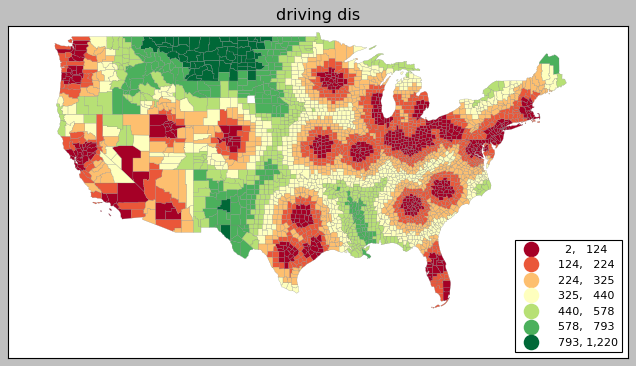

In [297]:
fig, ax = plt.subplots(1, figsize=(10,6))
a.plot(ax=ax,column='driving_distance',legend=True,cmap='RdYlGn',scheme='natural_breaks',k=7,
         edgecolor='grey',linewidth=.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
#leg1 = ax.get_legend()
#leg1.set_title('''Population Density #this is legend title; useful!
#2010 (pers/sq mi)''')
ax.title.set_text("driving dis")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

<Axes: >

[]

[]

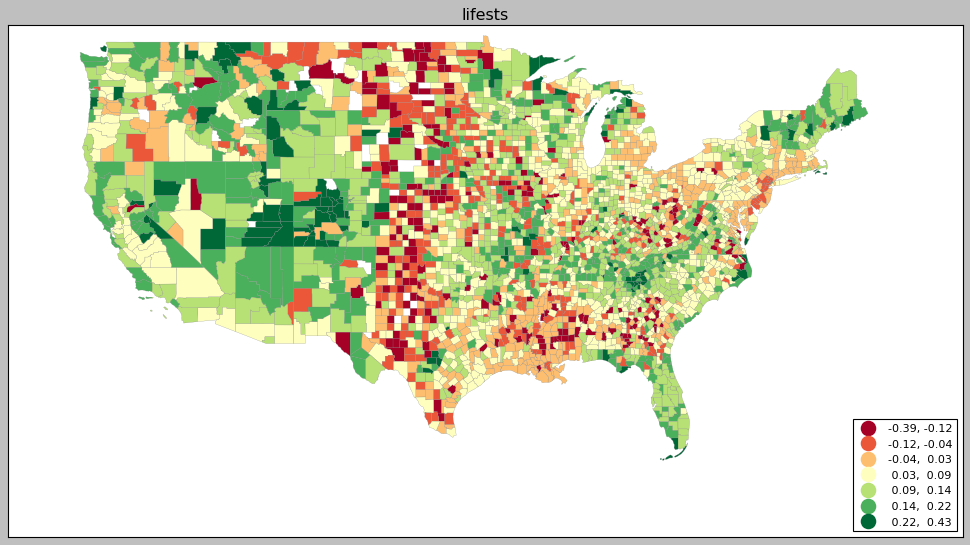

In [300]:
fig, ax = plt.subplots(1, figsize=(20,8))
a.plot(ax=ax,column='stat',legend=True,cmap='RdYlGn',scheme='natural_breaks',k=7,
         edgecolor='grey',linewidth=.2,legend_kwds= {"fmt": "{:,.2f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
#leg1 = ax.get_legend()
#leg1.set_title('''Population Density #this is legend title; useful!
#2010 (pers/sq mi)''')
ax.title.set_text("lifests")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

ha nj not happy; neither north east
neither midwest, and then this belt from tx to north, and east of tx happy incl ca

>>>zoom to these outliers like may put name on map etc

maybe spatial clustering and scatter etc etc

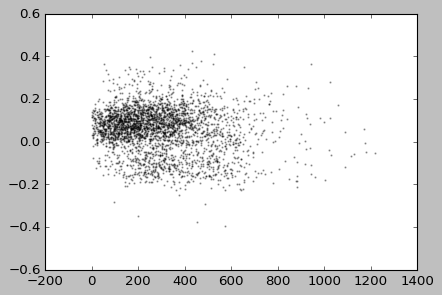

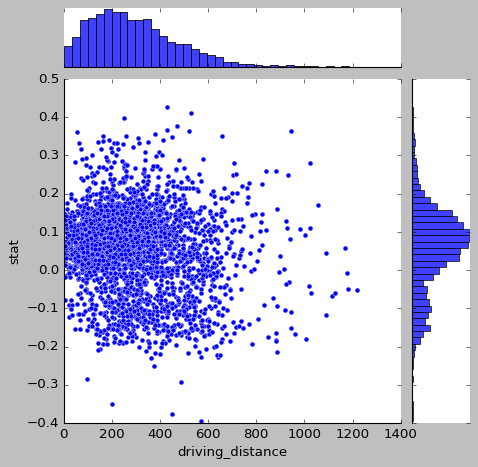

In [303]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(a.driving_distance,a.stat, c='black', s=1, alpha=0.3);
sns.jointplot(x ='driving_distance', y ='stat', data = a)

In [52]:
a.columns

Index(['STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'CENSUS2010POP',
       'POPESTIMATE2015', 'g', 'State', 'County', 'FIPS_x', 'StateName',
       'CountyName', 'Division', 'Region', 'CBSA', 'CBSA_Status', 'MetroDiv',
       'MetroDivTitle', 'LandArea', 'Pop05', 'AmenityScale', 'AmenityRank',
       'JanTemp', 'JanSun', 'JulTemp', 'JulHumid', 'Typography', 'FIPS_y',
       'county', 'stat', 'stat_se', 'salience', 'StateCounty', 'year',
       'ntweets', 'validtweets', 'popDen'],
      dtype='object')

In [96]:
# Sort the data by 'stat' and take top 100 and bottom 100
a_sorted = a.sort_values(by='stat', ascending=False)
#a_sorted.head(100)
a_sorted.tail(100)

top_bottom_100 = pd.concat([a_sorted.head(100), a_sorted.tail(100)])

,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,POPESTIMATE2015,g,State,County,FIPS_x,StateName,CountyName,Division,Region,CBSA,CBSA_Status,MetroDiv,MetroDivTitle,LandArea,Pop05,AmenityScale,AmenityRank,JanTemp,JanSun,JulTemp,JulHumid,Typography,FIPS_y,county,stat,stat_se,salience,StateCounty,year,ntweets,validtweets,popDen
1057,21,153,Kentucky,Magoffin County,13333,12791,21153,21: Kentucky,153,21153,Kentucky,Magoffin County,6: East South Central,3: South,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,309.44,13472,-1.67,3: 0 to -1,36.00,125.00,75.50,66.00,19: High hills,21.00,153.00,-0.16,0.27,0.36,21153,2014.00,31818,11807,41.34
2508,48,45,Texas,Briscoe County,1637,1515,48045,48: Texas,45,48045,Texas,Briscoe County,7: West South Central,3: South,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,900.25,1644,1.76,4: 0 to 1,38.30,216.00,78.90,38.00,"5: Tablelands, moderate relief",48.00,45.00,-0.16,0.66,0.34,48045,2014.00,919,328,1.68
2363,46,73,South Dakota,Jerauld County,2071,2021,46073,46: South Dakota,73,46073,South Dakota,Jerauld County,4: West North Central,2: Midwest,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,529.91,2136,-2.91,2: -1 to -2,14.90,159.00,74.00,49.00,4: Irregular plains,46.00,73.00,-0.16,0.67,0.32,46073,2015.33,2948,927,3.81
2573,48,175,Texas,Goliad County,7210,7517,48175,48: Texas,175,48175,Texas,Goliad County,7: West South Central,3: South,47020,1: Metropolitan Statistical Area,0: Not in a Metropolitan Division,,853.52,7102,1.61,4: 0 to 1,55.30,159.00,84.90,43.00,4: Irregular plains,48.00,175.00,-0.16,0.31,0.34,48175,2014.00,29144,10415,8.81
830,19,107,Iowa,Keokuk County,10511,10169,19107,19: Iowa,107,19107,Iowa,Keokuk County,4: West North Central,2: Midwest,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,579.19,11157,-3.95,2: -1 to -2,21.80,146.00,75.50,60.00,4: Irregular plains,19.00,107.00,-0.16,0.43,0.33,19107,2014.00,13215,4533,17.56
2163,40,129,Oklahoma,Roger Mills County,3647,3782,40129,40: Oklahoma,129,40129,Oklahoma,Roger Mills County,7: West South Central,3: South,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,1141.87,3311,-0.28,3: 0 to -1,37.00,183.00,82.40,44.00,"5: Tablelands, moderate relief",40.00,129.00,-0.16,0.54,0.34,40129,2014.00,5156,1792,3.31
513,13,273,Georgia,Terrell County,9315,9016,13273,13: Georgia,273,13273,Georgia,Terrell County,5: South Atlantic,3: South,10500,1: Metropolitan Statistical Area,0: Not in a Metropolitan Division,,335.37,10711,-0.21,3: 0 to -1,49.00,174.00,80.40,78.00,4: Irregular plains,13.00,273.00,-0.16,0.36,0.34,13273,2015.80,35879,12923,26.88
2832,51,111,Virginia,Lunenburg County,12914,12348,51111,51: Virginia,111,51111,Virginia,Lunenburg County,5: South Atlantic,3: South,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,431.70,13194,-2.17,3: 0 to -1,38.30,155.00,77.40,72.00,4: Irregular plains,51.00,111.00,-0.16,0.33,0.34,51111,2014.00,26824,9641,28.60
926,20,101,Kansas,Lane County,1750,1630,20101,20: Kansas,101,20101,Kansas,Lane County,4: West North Central,2: Midwest,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,717.22,1894,-0.90,3: 0 to -1,30.80,206.00,78.20,42.00,4: Irregular plains,20.00,101.00,-0.16,0.65,0.36,20101,2013.50,2749,1003,2.27
2066,39,111,Ohio,Monroe County,14642,14267,39111,39: Ohio,111,39111,Ohio,Monroe County,3: East North Central,2: Midwest,0: Not in a CBSA,0: Not in a CBSA,0: Not in a Metropolitan Division,,455.54,14698,-0.21,3: 0 to -1,32.30,115.00,75.20,59.00,18: Hills,39.00,111.00,-0.16,0.39,0.34,39111,2015.25,40200,14107,31.32


In [54]:
vc=a_sorted.head(100).STNAME.value_counts()
vc[vc > 3]
vc=a_sorted.tail(100).STNAME.value_counts() #aha! only georgia is in both!
vc[vc > 3]

,count
STNAME,
Colorado,21
Utah,10
Montana,7
North Carolina,6
Georgia,6
California,4
Tennessee,4


,count
STNAME,
Texas,12
Mississippi,11
North Dakota,10
Georgia,9
Nebraska,8
Kansas,7
Louisiana,6
Virginia,5
South Dakota,5


In [ ]:
#interesting lifests lowest in the mniddle of nowhere, but also highest in the middle of nowhere
#there is no large county abouve 200k!!!
#most are like less than 50k

#a[['stat', 'POPESTIMATE2015', 'popDen','STNAME', 'CTYNAME']]

<Figure size 960x560 with 0 Axes>

<Axes: xlabel='POPESTIMATE2015', ylabel='stat'>

Text(0.5, 1.0, 'Top 100 and Bottom 100 Counties: Life Satisfaction (stat) vs. Population (0-200k)')

Text(0.5, 0, 'Population Estimate (2015)')

Text(0, 0.5, 'Life Satisfaction (stat)')

(0.0, 200000.0)

Text(1000, 0.06529778928690312, 'mean')

Text(26403.5, -0.57, 'median')

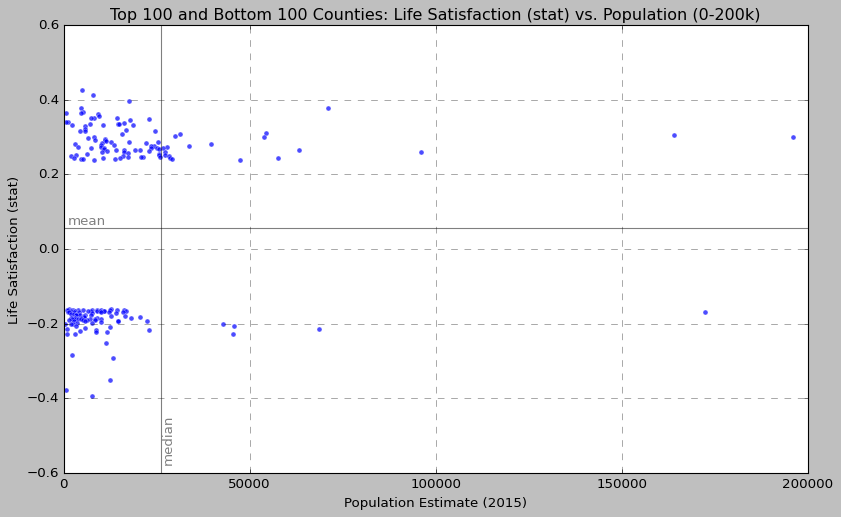

In [77]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=top_bottom_100, x='POPESTIMATE2015', y='stat', alpha=0.7) #hue='stat', palette='coolwarm_r'

plt.title('Top 100 and Bottom 100 Counties: Life Satisfaction (stat) vs. Population (0-200k)')
plt.xlabel('Population Estimate (2015)')
plt.ylabel('Life Satisfaction (stat)')
plt.xlim(0, 200000)  # Setting x-axis range as requested
plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(title='stat ')

plt.axhline(a.stat.mean(), color='black', linestyle='-', alpha=0.5)
plt.text(x=1000, y=a.stat.mean()+.01, s='mean', color='grey')

plt.axvline(a.POPESTIMATE2015.median(), color='black', linestyle='-', alpha=0.5)
plt.text(x=a.POPESTIMATE2015.median()+100, y=-.57, s='median', color='grey',rotation='vertical')

plt.show()

In [23]:
a[['stat', 'POPESTIMATE2015', 'popDen']].corr() #ah bummer
a[['stat', 'AmenityScale', 'JanTemp']].corr() #yes on amenity scale
a[['AmenityScale', 'POPESTIMATE2015']].corr()

NameError: name 'a' is not defined

In [ ]:
#a[['AmenityScale', 'POPESTIMATE2015','STNAME', 'CTYNAME']] #aha! some are big and some tiny!

In [ ]:
a.select_dtypes(include=[np.number]).corr()['stat'].sort_values(ascending=False)

In [ ]:
a.POPESTIMATE2015.describe()

In [ ]:
a10k = a[a['POPESTIMATE2015']  < 10000]
a20k = a[a['POPESTIMATE2015']  < 20000]
a500k = a[a['POPESTIMATE2015'] < 500000]
a100k = a[a['POPESTIMATE2015'] < 100000]
a1m   = a[a['POPESTIMATE2015'] < 1000000]

<Figure size 1200x640 with 0 Axes>

<Axes: xlabel='POPESTIMATE2015', ylabel='stat'>

Text(0.5, 1.0, 'LOWESS Smooth: stat vs. POPESTIMATE2015')

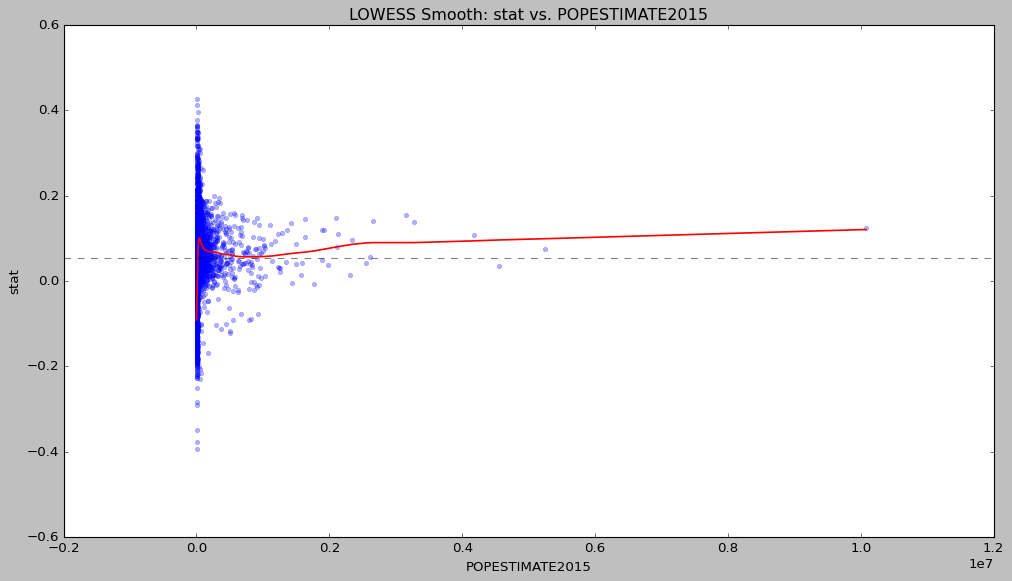

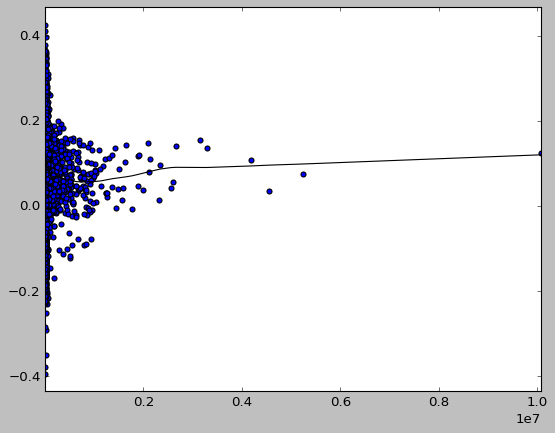

In [305]:
plt.figure(figsize=(15, 8))
sns.regplot(data=a, y='stat', x='POPESTIMATE2015', lowess=True,
            scatter_kws={'alpha':0.3, 's':16},
            line_kws={'color':'red'})
plt.axhline(0.055, color='black', linestyle='--', alpha=0.5)
plt.title('LOWESS Smooth: stat vs. POPESTIMATE2015')
plt.show()

#lowess useful to figure out nonlinearities in relationship
import statsmodels.api as sm
smoothed = sm.nonparametric.lowess(exog=a.POPESTIMATE2015, endog=a.stat, frac=0.3) #lo, more wiggly

fig, ax = plt.subplots()
ax.scatter(a.POPESTIMATE2015,a.stat)
ax.plot(smoothed[:, 0], smoothed[:, 1], c="k")
plt.autoscale(enable=True, axis="x", tight=True)
#https://www.statsmodels.org/dev/examples/notebooks/generated/lowess.html
#https://james-brennan.github.io/posts/lowess_conf/
#https://stackoverflow.com/questions/31104565/confidence-interval-for-lowess-in-python
#https://stackoverflow.com/questions/42637579/how-to-compute-and-plot-a-lowess-curve-in-python

In [ ]:
plt.figure(figsize=(15, 8)) #interesting very smallest ones not super happy
sns.regplot(data=a20k, y='stat', x='POPESTIMATE2015', order=2,
            scatter_kws={'alpha':0.3, 's':6},
            line_kws={'color':'red'})
plt.axhline(0.055, color='black', linestyle='--', alpha=0.5)
plt.title('Quadratic Regression: stat vs. POPESTIMATE2015')
plt.show()

In [ ]:
a.stat.mean()
plt.figure(figsize=(15, 8))
sns.regplot(data=a, y='stat', x='POPESTIMATE2015', order=2,
            scatter_kws={'alpha':0.3, 's':16},
            line_kws={'color':'red'})
plt.axhline(0.055, color='black', linestyle='--', alpha=0.5)
plt.title('Quadratic Regression: stat vs. POPESTIMATE2015')
plt.show()

In [ ]:
#appendix only too resprtictive
plt.figure(figsize=(15, 8))
sns.regplot(data=a100k, y='stat', x='POPESTIMATE2015', order=2,
            scatter_kws={'alpha':0.3, 's':2},
            line_kws={'color':'red'})
plt.title('Quadratic Regression: stat vs. POPESTIMATE2015')
plt.show()

In [25]:
#this one to papaer
plt.figure(figsize=(15, 8))
sns.regplot(data=a1m, y='stat', x='POPESTIMATE2015', order=2,
            scatter_kws={'alpha':0.3, 's':2},
            line_kws={'color':'red'})
plt.title('Quadratic Regression: stat vs. POPESTIMATE2015')
plt.show()

<Figure size 1200x640 with 0 Axes>

NameError: name 'a1m' is not defined

<Figure size 1200x640 with 0 Axes>

yes actually makes sense! somewhere around 300-600k starts to flip like in my cities paper when am city is too big :)

In [ ]:
a5kd = a[a['popDen'] < 5000]
a1kd = a[a['popDen'] < 1000]

In [ ]:
plt.figure(figsize=(15, 8))
sns.regplot(data=a5kd, y='stat', x='popDen', order=2,
            scatter_kws={'alpha':0.3, 's':2},
            line_kws={'color':'red'})

In [ ]:
plt.figure(figsize=(15, 8))
sns.regplot(data=a1kd, y='stat', x='popDen', order=2,
            scatter_kws={'alpha':0.3, 's':2},
            line_kws={'color':'red'})

In [ ]:
model = sm.ols(formula='stat ~ AmenityScale * POPESTIMATE2015', data=a).fit()
print(model.summary())

yes rural amenities better